In [279]:
"""
get dN/dZ of galaxy surveys
"""

'\nget dN/dZ of galaxy surveys\n'

In [203]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [204]:
import numpy as np, sys, os, scipy as sc
import tools_nx2pt

from pylab import *
cmap = cm.RdYlBu
rcParams['figure.dpi'] = 150


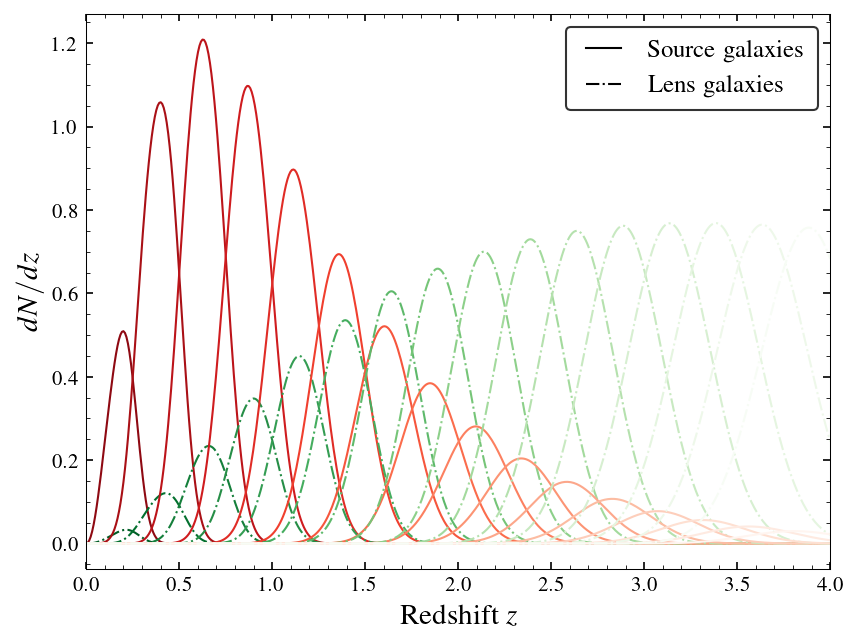

In [205]:
clf()
fsval = 14
#experiment = 'euclid_spec'
experiment = 'roman_hls'
#zbin_arr = [0.21, 0.49, 0.62, 0.73, 0.84, 0.96, 1.09, 1.24, 1.45, 2.04]
#zbin_arr = [0.84, 0.96, 1.09, 1.24, 1.45, 2.04]
zbinwidth = 0.2
zbin_arr = [(z, z+zbinwidth) for z in np.arange(0., 4., zbinwidth)]

if (1):
    zbinwidth = 0.25
    zbin_arr = [(z, z+zbinwidth) for z in np.arange(0., 4., zbinwidth)]
    

color_arr = [cm.Reds_r(int(d)) for d in np.linspace(20, 255, len(zbin_arr))]
color_arr_v2 = [cm.Greens_r(int(d)) for d in np.linspace(20, 255, len(zbin_arr))]
dndz_lensgalsforclus_dic = {}
dndz_sourcegalsforshear_dic = {}
zbin_mid_arr = []
for cntr, zbin in enumerate( zbin_arr ):
    zbin_mid = (zbin[0] + zbin[1] )/2.
    zarr_source, dndz_bin_source, bias_source = tools_nx2pt.get_dngal_dz_photoz('%s_source' %(experiment), zbin)
    dndz_lensgalsforclus_dic[zbin_mid] = [zarr_source, dndz_bin_source, bias_source]
    zarr_lens, dndz_bin_lens, bias_lens = tools_nx2pt.get_dngal_dz_photoz('%s_lens' %(experiment), zbin)
    dndz_sourcegalsforshear_dic[zbin_mid] = [zarr_lens, dndz_bin_lens, bias_lens]
    plot( zarr_source, dndz_bin_source, color = color_arr[cntr])
    plot( zarr_lens, dndz_bin_lens, color = color_arr_v2[cntr], ls = '-.')
    zbin_mid_arr.append( zbin_mid )
xlim(0., 4.)
plot([], [], 'k-', label = r'Source galaxies')
plot([], [], 'k-.', label = r'Lens galaxies')
xlabel(r'Redshift $z$', fontsize = fsval)
ylabel(r'$dN/dz$', fontsize = fsval)
legend(loc = 1, fontsize = fsval-2)
show()

# Obtain data vectors

In [206]:
ell = np.geomspace(2, 1000, 10)
data_vector_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell)

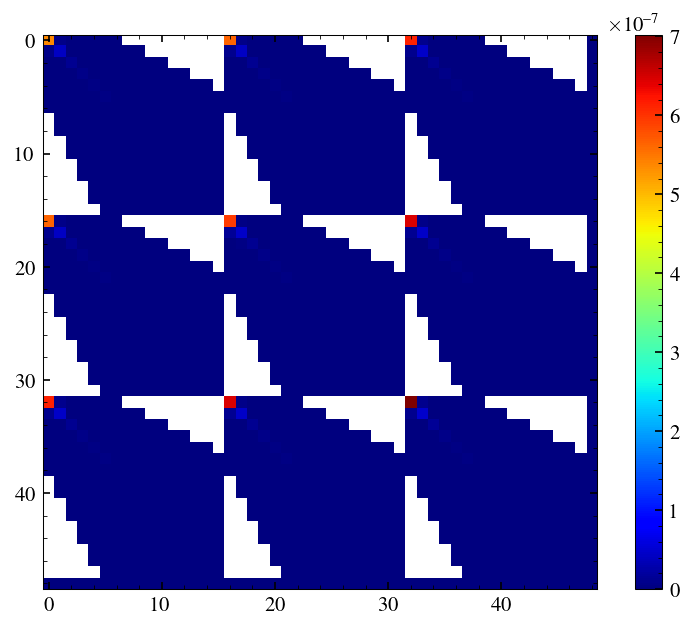

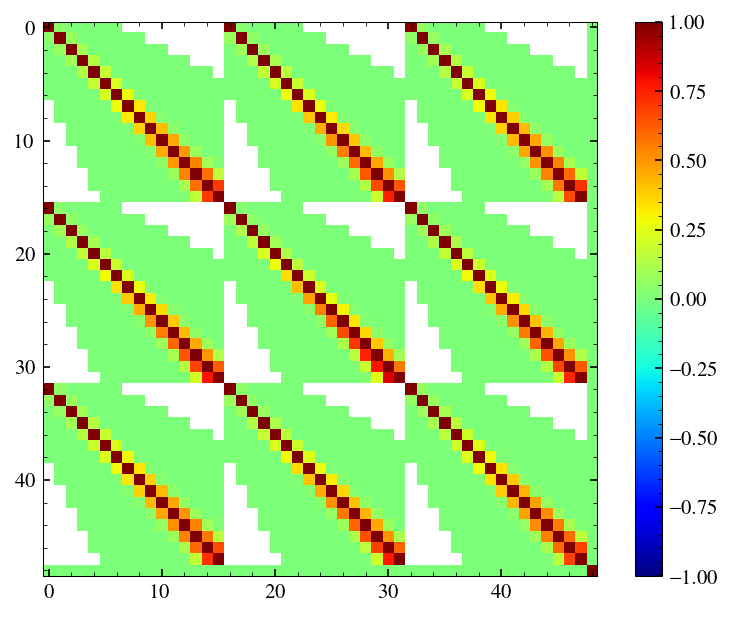

SystemExit: 

In [278]:
#get cov
total_zbins = len( zbin_mid_arr )
total_ellbins = len(ell)
if 'cl_k_k' in data_vector_dic:
    total_observables = 4
    cov_mat_ndim = (total_observables-1) * total_zbins
    cov_mat_ndim = cov_mat_ndim + 1
else:
    total_observables = 3
    cov_mat_ndim = total_observables * total_zbins
##print(cov_mat_ndim); sys.exit()
k_k_zkey = (1100., 1100.)
obs_key_arr = ['cl_s_s', 'cl_g_s', 'cl_g_g']

for elcntr, elval in enumerate( ell ):
    full_cov_mat = np.zeros( (cov_mat_ndim, cov_mat_ndim) )
    ###print(full_cov_mat.shape); sys.exit()

    if 'cl_k_k' in data_vector_dic: #CMB-lensing
        curr_k_k = data_vector_dic['cl_k_k'][k_k_zkey][elcntr]
        full_cov_mat[-1, -1] = curr_k_k**2.
        
        #loop over all zbins and fill the covmat now
        tmpcovindex = 0
        for offdiagiter in range( tot_off_diag_iter ):
            curr_obs_key_split = obs_key_arr[offdiagiter].split('_')
            curr_obs_key = 'cl_k_%s' %(curr_obs_key_split[-1])
            for zcntr, z in enumerate( zbin_mid_arr ):
                curr_k_x = data_vector_dic[curr_obs_key][(z1,z2)][elcntr]
                
                full_cov_mat[-1, tmpcovindex] = curr_k_x * curr_k_k
                full_cov_mat[tmpcovindex, -1] = curr_k_x * curr_k_k
                tmpcovindex += 1
    
    #off-diagonals
    tot_off_diag_iter = len(obs_key_arr)
    for offdiagiter1 in range( tot_off_diag_iter ):
        for offdiagiter2 in range( tot_off_diag_iter ):
            ##if offdiagiter1 == offdiagiter2: continue
            obs_key1, obs_key2 = obs_key_arr[offdiagiter1], obs_key_arr[offdiagiter2]
            curr_cov_mat = np.zeros( (total_zbins, total_zbins) )
            for z1cntr, z1 in enumerate( zbin_mid_arr ):
                for z2cntr, z2 in enumerate( zbin_mid_arr ):
                    if obs_key1 ==  obs_key2 and obs_key1 == ['cl_g_s']:
                        curr_g_s = data_vector_dic[obs_key1][(z1,z2)][elcntr]
                        curr_g_g = data_vector_dic['cl_g_g'][(z1,z2)][elcntr]
                        curr_s_s = data_vector_dic['cl_s_s'][(z1,z2)][elcntr]
                        curr_cov_mat[(z1cntr, z2cntr)] = 0.5 * ( curr_g_s**2. + curr_g_g * curr_s_s )
                    else:
                        curr_data_val1 = data_vector_dic[obs_key1][(z1,z2)][elcntr]
                        curr_data_val2 = data_vector_dic[obs_key2][(z1,z2)][elcntr]
                        curr_cov_mat[(z1cntr, z2cntr)] = curr_data_val1 * curr_data_val2
            
            s1 = total_zbins * offdiagiter1
            e1 = s1 + total_zbins
            s2 = total_zbins * offdiagiter2
            e2 = s2 + total_zbins
            full_cov_mat[s1:e1, s2:e2] = curr_cov_mat
            ###imshow(full_cov_mat); colorbar();show(); 
    ##sys.exit()
                
    #corr mat
    full_corr_mat = tools_nx2pt.corr_from_cov(full_cov_mat)
    to_plot = np.copy(full_cov_mat)
    to_plot[to_plot==0.] = None
    
    imshow(to_plot); colorbar(); show()

    to_plot = np.copy(full_corr_mat)
    to_plot[to_plot==0.] = None
    
    imshow(to_plot, vmin = -1, vmax = 1.); colorbar(); show()
    sys.exit()

In [229]:
full_cov_mat[s:e, s:e]

(49, 49)

In [34]:
import pyccl as ccl
import numpy as np

# 1. Initialize Cosmology
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=0.67, sigma8=0.81, n_s=0.96)

# 2. Define Tracers (Redshift distributions n(z) and bias)
# CMB lensing
t_cmb = ccl.CMBLensingTracer(cosmo, z_source=1100.)

if (1):
    color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, len(zbin_arr))]
    clf()
    cl_dic = {}
    for cntr, zbin in enumerate( zbin_arr ):
        print(cntr)
        zarr, dndz_bin = tools_nx2pt.get_dngal_dz_photoz(experiment, zbin)
        z1, z2 = zbin
        bias_model = (1+zarr)*1.2
        """
        if (0):##z2<=0.8:
            bias_model = 1.5
        else:
            bias_model = (1+zarr)**2.
        """
        print(bias_model)
        plot(zarr, bias_model, color = color_arr[cntr])
        curr_t_g = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(zarr, dndz_bin), 
                                     bias=(zarr, bias_model))
    
        # 3. Define Angular Scales
        ell = np.geomspace(2, 2000, 20)
        
        # 4. Compute a Gaussian Covariance Block
        # This calculates Cov(Cl_gs, Cl_gs) for a given sky fraction
        curr_cl_g_g = ccl.angular_cl(
            cosmo,
            curr_t_g, curr_t_g,
            ell=ell,
        )
        curr_cl_kappa_g = ccl.angular_cl(
            cosmo,
            t_cmb, curr_t_g,
            ell=ell,
        )
        cl_dic[cntr] = [ell, curr_cl_g_g, curr_cl_kappa_g]
    show()
clf()
for cntr, zbin in enumerate( zbin_arr ):
    ell, curr_cl_g_g, curr_cl_kappa_g = cl_dic[cntr]
    plot(ell, curr_cl_g_g, color = color_arr[cntr])
    #plot(ell, curr_cl_kappa_g, color = color_arr[cntr], ls = '--')
show()

SystemExit: 

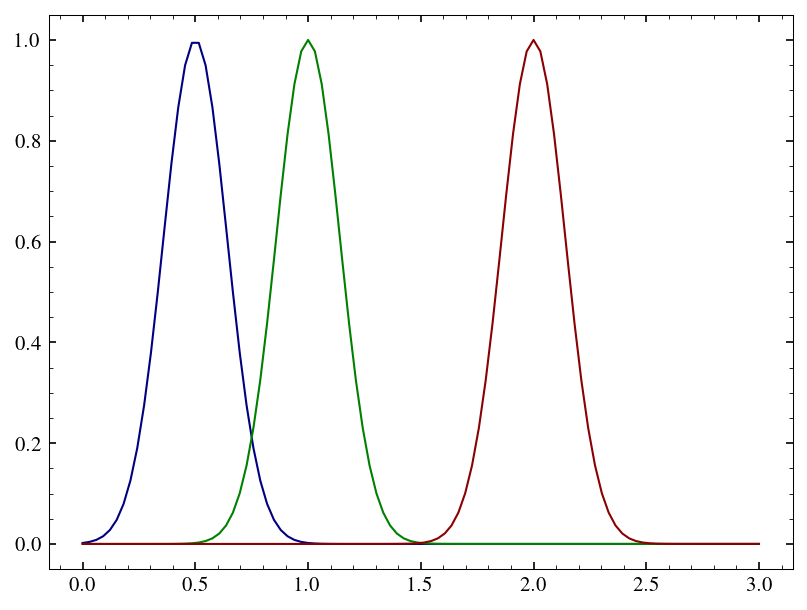

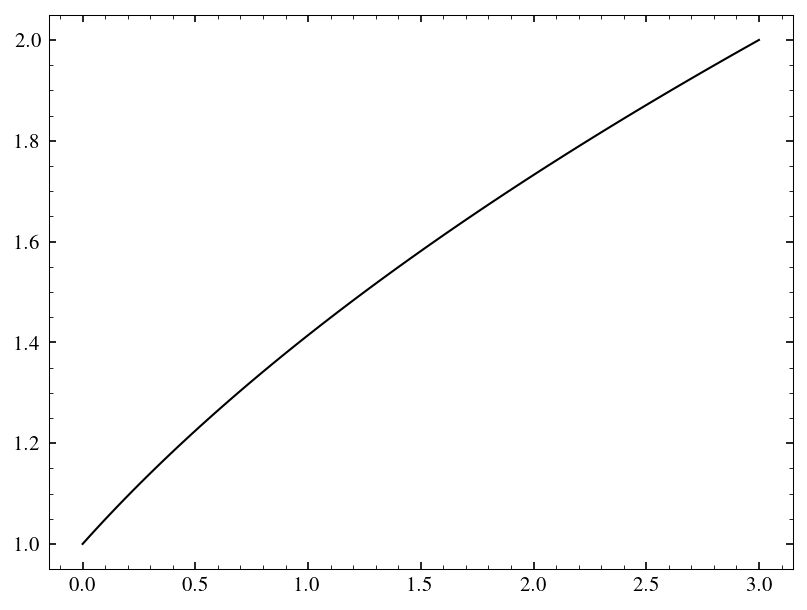

In [35]:
import pyccl as ccl
import numpy as np

# 1. Initialize Cosmology
cosmo = ccl.Cosmology(
    Omega_c=0.27, Omega_b=0.045, h=0.67, sigma8=0.81, n_s=0.96)

# 2. Define Tracers (Redshift distributions n(z) and bias)
z = np.linspace(0., 3., 100)
nz_lens = np.exp(-((z-0.5)/0.1)**2)   # Lens galaxies (Clustering)
nz_source = np.exp(-((z-1.0)/0.2)**2) # Source galaxies (Shear)

nz_lens_lowz = np.exp(-((z-0.5)/0.2)**2) # Low-z Lens galaxies (Clustering)
nz_lens_midz = np.exp(-((z-1.0)/0.2)**2) # Mid-z Lens galaxies (Clustering)
nz_lens_highz = np.exp(-((z-2.0)/0.2)**2) # High-z Lens galaxies (Clustering)

clf()
#plot(z, nz_lens)
#plot(z, nz_source)
plot(z, nz_lens_lowz, color = 'navy')
plot(z, nz_lens_midz, color = 'green')
plot(z, nz_lens_highz, color = 'darkred')
show()

bias_model = np.ones_like(z)*1.2
bias_model = np.sqrt(1+z)
# NumberCounts = Galaxy Clustering Tracer
t_g = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens), 
                             bias=(z, bias_model))

t_lowzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_lowz), 
                             bias=(z, bias_model))

t_midzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_midz), 
                             bias=(z, bias_model))

t_highzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_highz), 
                             bias=(z, bias_model))

clf()
plot(z, bias_model)
show()

# WeakLensing = Cosmic Shear Tracer
t_s = ccl.WeakLensingTracer(cosmo, dndz=(z, nz_source))

# CMB lensing
t_cmb = ccl.CMBLensingTracer(cosmo, z_source=1100.)

# 3. Define Angular Scales
ell = np.geomspace(2, 2000, 20)

# 4. Compute a Gaussian Covariance Block
# This calculates Cov(Cl_gs, Cl_gs) for a given sky fraction
fsky = 0.1  # 10% of the sky
cl_gg = ccl.angular_cl(
    cosmo,
    t_g,
    t_s,
    ell=ell,
)
cl_ss = ccl.angular_cl(
    cosmo,
    t_s,
    t_s,
    ell=ell,
)
cl_gs = ccl.angular_cl(
    cosmo,
    t_s,
    t_g,
    ell=ell,
)
cl_kappakappa = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_cmb,
    ell=ell,
)
cl_kappas = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_s,
    ell=ell,
)
cl_kappag = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_g,
    ell=ell,
)

cl_kappalowzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_lowzg,
    ell=ell,
)
cl_kappamidzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_midzg,
    ell=ell,
)

cl_kappahighzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_highzg,
    ell=ell,
)





In [37]:
t_cmb

<pyccl.tracers.Tracer>
	num       kernel             transfer       prefac  bessel 
	 0  0xc732f1e0500d330c         None           1       -1   

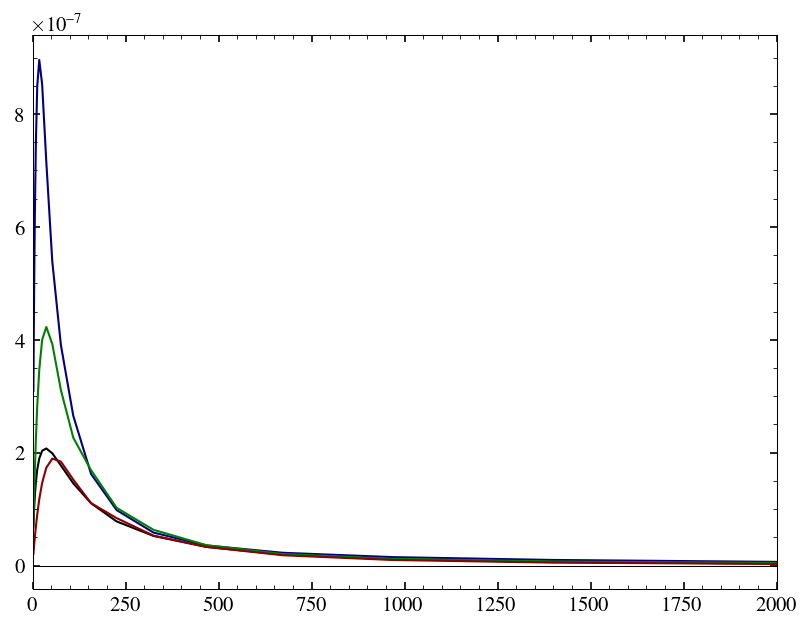

In [38]:
clf()
dl_fac = 1. ##ell * (ell+1)/2/np.pi
# plot(ell, cl_gg)
# plot(ell, cl_ss)
# plot(ell, cl_gs)
plot(ell, cl_kappakappa)
plot(ell, cl_kappalowzg, color = 'navy')
plot(ell, cl_kappamidzg, color = 'green')
plot(ell, cl_kappahighzg, color = 'darkred')
#plot(ell, cl_kappag)
#plot(ell, cl_kappas)
axhline(lw = 0.5)
xlim(0, 2000)
show()

# Check LSST data vectors

(27, 20)


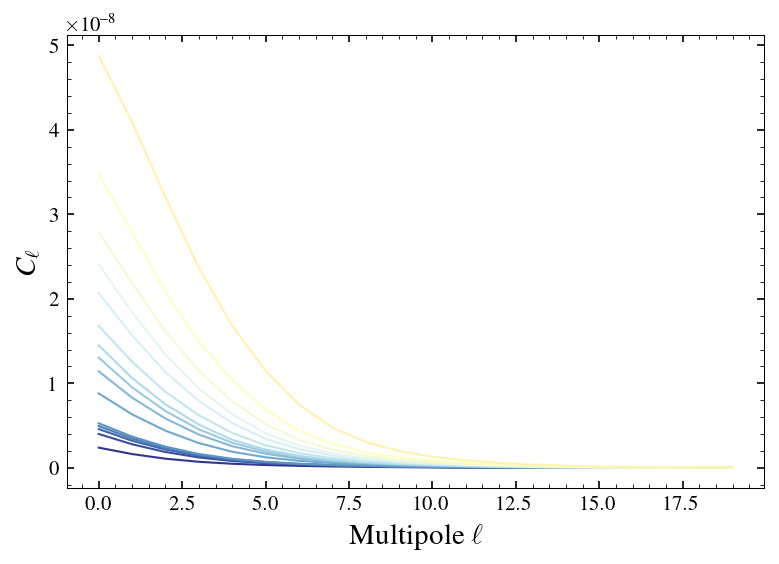

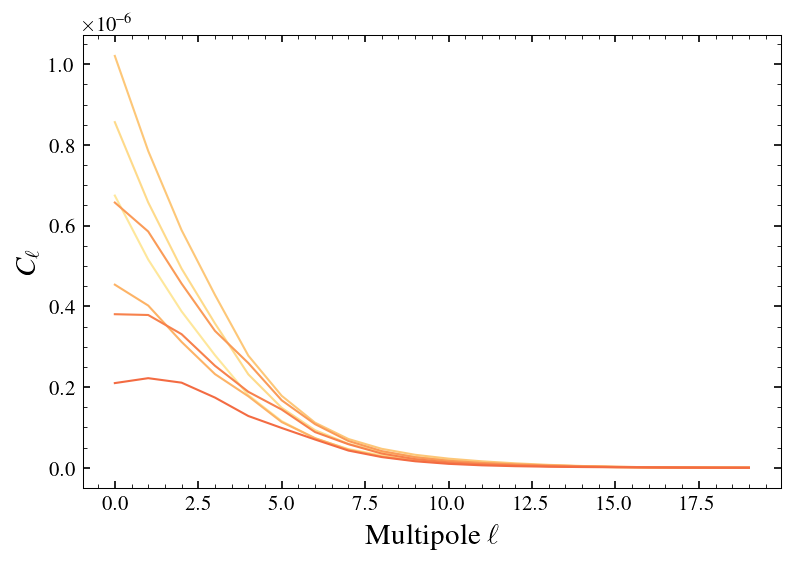

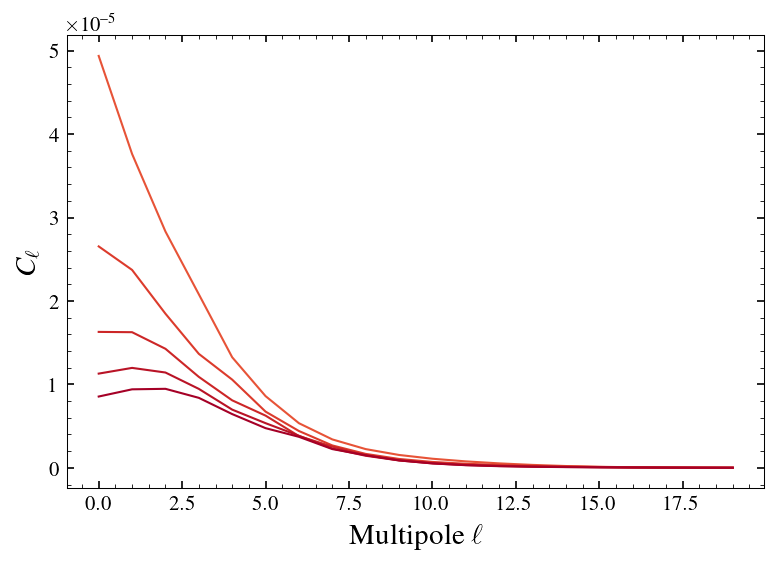

In [19]:
lsstfd = '/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/data/LSST_3x2pt/srd_comsology/data_vectors/'
lsstfname = '%s/cmb_y1_3x2pt_data_vector_cosmo_priors.npy' %(lsstfd)
lsstdata = np.load( lsstfname, allow_pickle=True )
print( lsstdata.shape )

color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, 27)]
clf()
fsval = 14
for iii in range(15):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()

clf()
for iii in range(15, 22):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


clf()
for iii in range(22, 27):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


(27, 20)


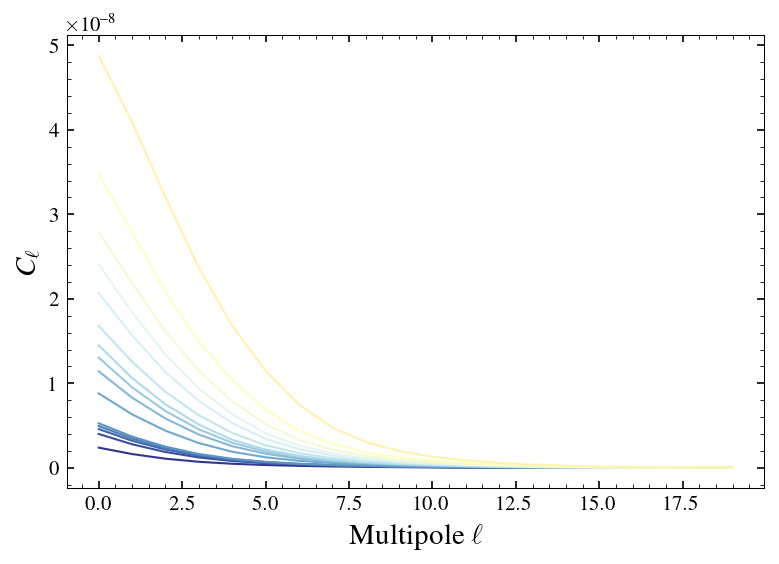

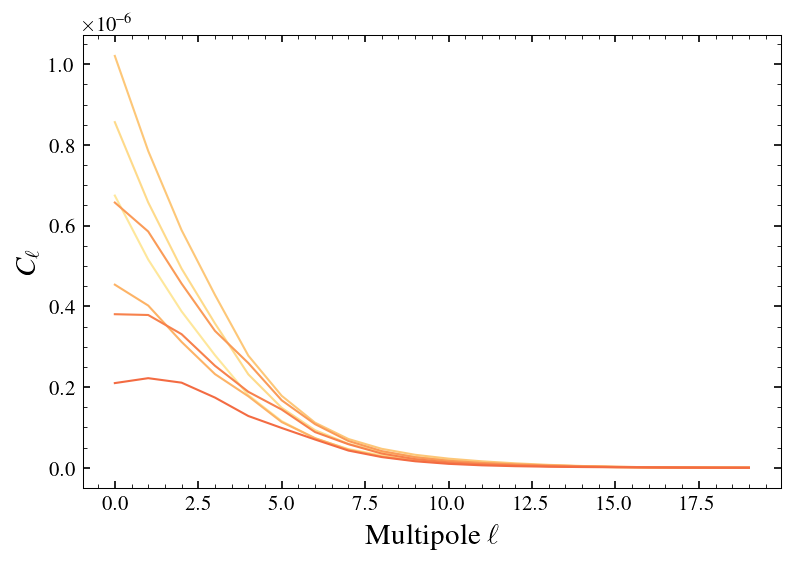

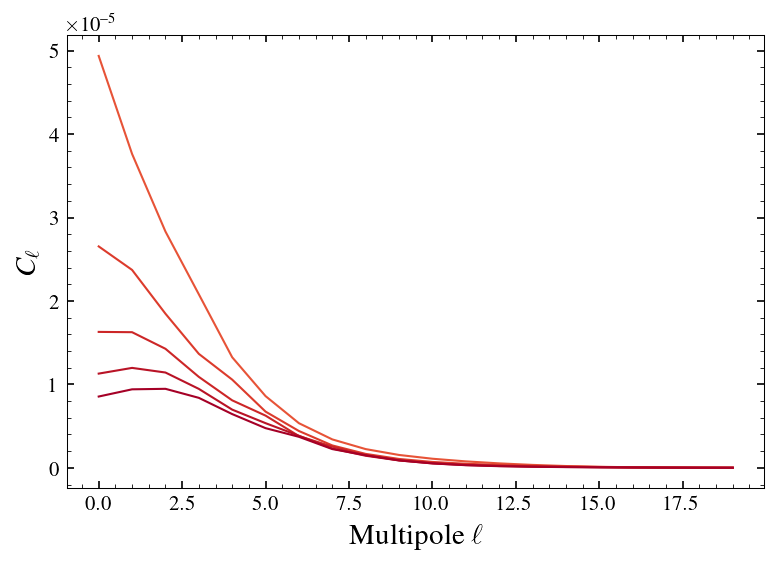

In [20]:
lsstfd = '/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/data/LSST_3x2pt/srd_comsology/data_vectors/'
lsstfname = '%s/cmb_y1_3x2pt_data_vector_all_priors.npy' %(lsstfd)
lsstdata = np.load( lsstfname, allow_pickle=True )
print( lsstdata.shape )

color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, 27)]
clf()
fsval = 14
for iii in range(15):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()

clf()
for iii in range(15, 22):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


clf()
for iii in range(22, 27):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()
